<a href="https://colab.research.google.com/github/Marija1000/project/blob/main/2025_03_08_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://drive.google.com/uc?export=view&id=1UO2urRciECzoKE_vHy4RMGfFbkOWOGlW" alt="SDA logo" align="left" width="100px" hspace="10px" vspace="10px"/>

# 1. Matplotlib

* knihovna pro vytváření 2D a 3D grafů
* rozhraní podobné MATLABu
* cca 70 tisíc řádků kódu
* modul `pyplot` - vytváření grafů/výkresů
* domovská stránka s dokumentací:<br>https://matplotlib.org/index.html

In [ ]:
# kouzelná funkce, která vykreslí obrázek do sešitu (notebooku)
# (místo zobrazení výpisu objektu obrázku)
%matplotlib inline

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt  # konvenční alias

# ekvivalentní zápisu
# from matplotlib import pyplot as plt

### První výkres

Pro **<font color='##13e5e1'>vyvtvoření grafu</font>**, používáme funkci `plt.subplots()`, která vrací dva objekty:
* `fig` - sloužící jako kontejner na grafy
* `ax/axes` - představující samotný/é graf/grafy

Pro **<font color='##13e5e1'>začlenění vizuálních prvků</font>** do grafu využíváme různé operace s objektem `ax`, např. voláním metod, jako je `.plot()`, můžeme přidávat různé typy vizualizací, např. čárové grafy.

Po přidání požadovaných vizualizací můžeme zobrazit výsledný graf pomocí funkce `plt.show()`. Ona **<font color='##13e5e1'>zobrazuje graf</font>** v samostatném okně nebo v rozhraní notebooku.

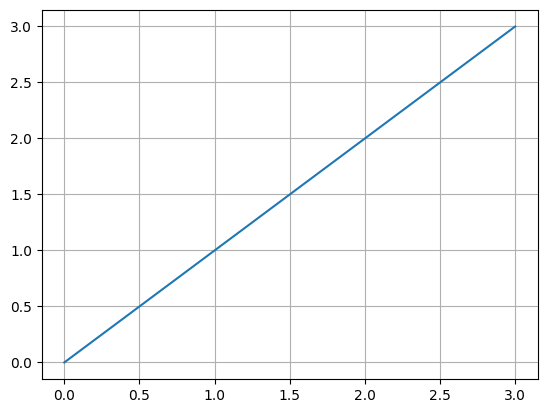

In [ ]:
# vytvoříme plátno (kontejner grafu)
fig, ax = plt.subplots()

# data pro vizualizaci
x = [0, 1, 2, 3]
y = [0, 1, 2, 3]

# čárový graf
ax.plot(x, y)
ax.grid()

# zobrazení grafu
plt.show()

Chcete-li do grafu matplotlib přidat mřížku, můžete použít metodu `.grid()`. Taková mřížka je vizuální prvek, který lze přidat do grafu, aby se zlepšil jeho vzhled a usnadnila interpretace dat. Skládá se z **<font color='##13e5e1'>vodorovných a svislých čar</font>**, které jsou zarovnány s hlavními body na osách X a Y.

Ve výchozím nastavení funkce `.grid()` zapíná čáry mřížky světle šedou barvou, ale máte možnost **<font color='##13e5e1'>přizpůsobit mřížku</font>** úpravou jejího vzhledu. Funkce `.grid()` přijímá nepovinné parametry, jako např.
* `color`
* `linestyle`
* `linewidth`
* `alpha`

pro upravení barvy, stylu čar, tloušťky a průhlednosti čar mřížky.

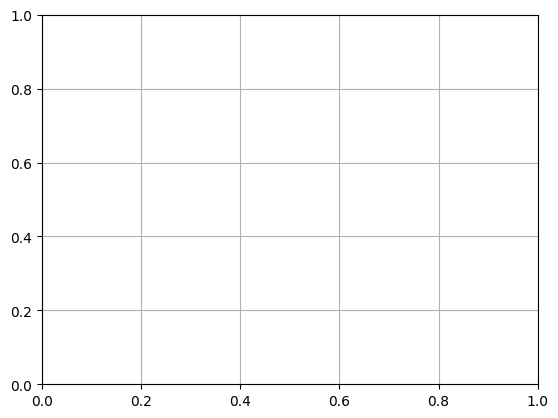

In [ ]:
fig, ax = plt.subplots()

ax.grid() #mřížka
plt.show()

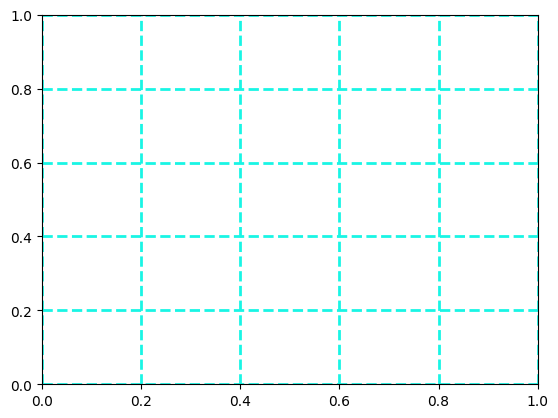

In [ ]:
fig,ax = plt.subplots()

ax.grid(
    color='#19f5e5',
    linestyle='--',
    linewidth=2,
    alpha=1
)

plt.show()

Existuje mnoho dalších parametrů. Více najdete na oficiální dokumentaci: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.grid.html

Například parametr `axis` v metodě `.grid()` umožňuje řídit, na které ose se vykreslí čáry mřížky:
* `axis='x'` pro přidání mřížkových čar pouze podél osy X
* `axis='y'` pro přidání mřížek pouze podél osy Y.

Chcete-li zahrnout mřížky na obou osách, můžete nastavit `axis='both'`, což je výchozí nastavení.

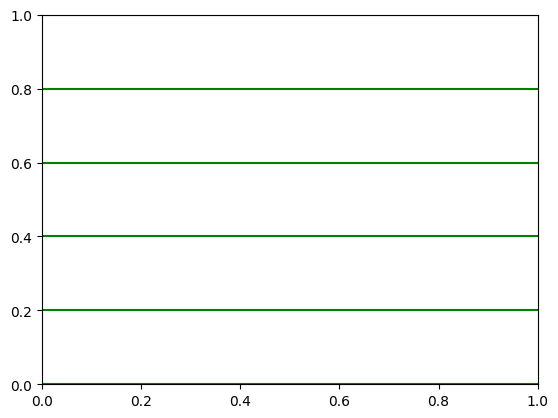

In [ ]:
fig,ax = plt.subplots()

ax.grid(
    axis='y',
    color='green',
    linewidth=1.5,
)

plt.show()

<img src="https://drive.google.com/uc?export=view&id=141XOz6N4nk8Ru1sAl7vOsAToCLrSFCAX" alt="SDA logo" width="150" align='right'/>
<br>

## Počasí v Seattlu

Nejlepším způsobem, jak ukázat užitečnost této knihovny, je použít skutečná data:

In [ ]:
url='https://raw.githubusercontent.com/matzim95/ML-datasets/master/weather.csv'

weather=pd.read_csv(
    url,
    parse_dates=True,
    index_col='date'
)

In [ ]:
weather.head()

,precipitation,temp_max,temp_min,wind,weather
date,,,,,
2012-01-01,0.0,12.8,5.0,4.7,drizzle
2012-01-02,10.9,10.6,2.8,4.5,rain
2012-01-03,0.8,11.7,7.2,2.3,rain
2012-01-04,20.3,12.2,5.6,4.7,rain
2012-01-05,1.3,8.9,2.8,6.1,rain


### Základní vizualizace časových řad

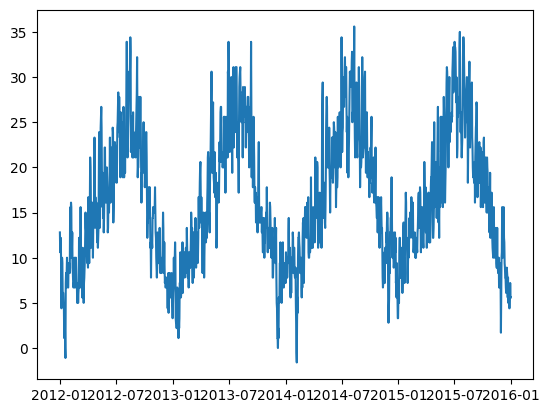

In [ ]:
fig, ax = plt.subplots()

# nakresli graf pomocí "axis" objektu
ax.plot(weather.index, weather['temp_max'])
plt.show()

### Upravte velikost plátna (kontejneru)
Všimněte si, že popisky na grafu nejsou čitelné a výchozí velikost grafu není optimální.

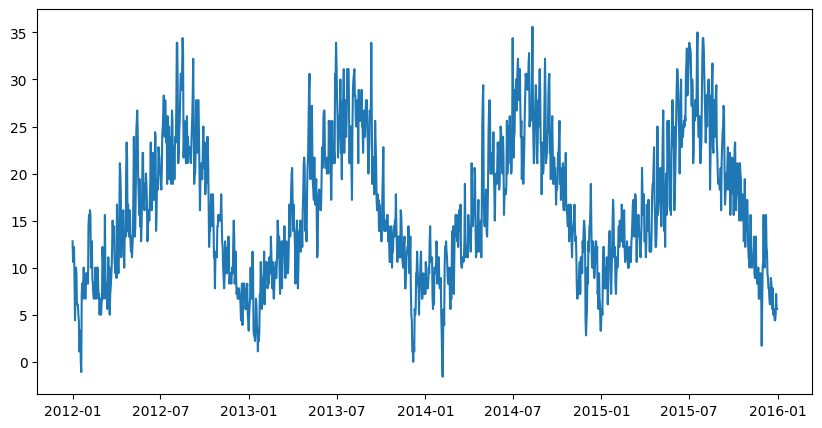

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(weather.index, weather['temp_max'])
plt.show()

### Zobrazení více grafů/vrstev na jedné grafice

Co když chcete kreslit **<font color='##13e5e1'>dva nebo více grafů v jednom grafu</font>** v matplotlibu, což umožňuje vizuální porovnání a analýzu více souborů dat nebo funkcí v rámci jednoho obrázku?

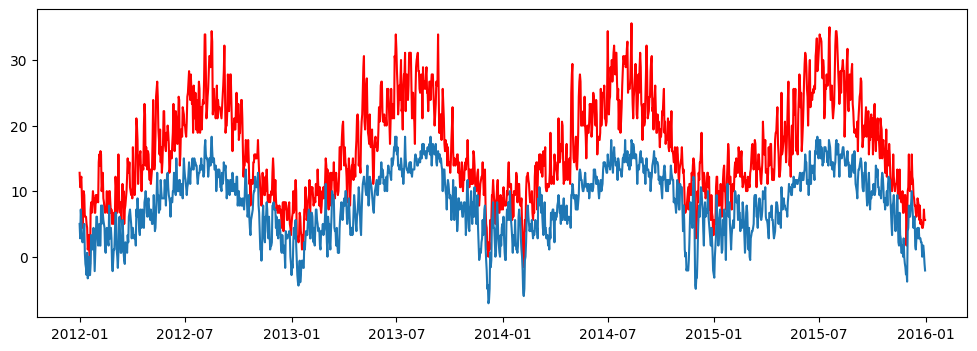

In [ ]:
fig, ax=plt.subplots(figsize=(12, 4))

ax.plot(weather.index, weather['temp_max'], color='red')
ax.plot(weather.index, weather['temp_min'])
plt.show()

### Zadejte legendu

Všimněte si, že můžeme pouze **<font color='##13e5e1'>hádat, která barva odpovídá kterému sloupci</font>**. Zde je to snadné, protože data pocházejí z jedné oblasti (tj. Seattlu) a popisují minimální a maximální teplotu. Co kdyby pocházela z různých míst nebo popisovala vlastnosti, které by nebylo tak zřejmé rozlišit na základě grafu?

Pokud chcete **<font color='##13e5e1'>přidat do grafu legendu</font>** v matplotlibu, které vám umožní rozlišit a identifikovat různé datové sady nebo prvky grafu ve vizualizaci, postupujte podle následujících kroků:
* přiřaďte popisek ke každému grafu
* po vykreslení všech potřebných prvků zavolejte funkci `plt.legend()` a zobrazte legendu v grafu.

Vzhled legendy můžete v případě potřeby přizpůsobit pomocí volitelných parametrů dostupných ve funkci `plt.legend()`. Tyto parametry umožňují ovládat polohu, zarovnání, velikost písma a další vlastnosti legendy.

Zobrazte graf pomocí funkce `plt.show()`.

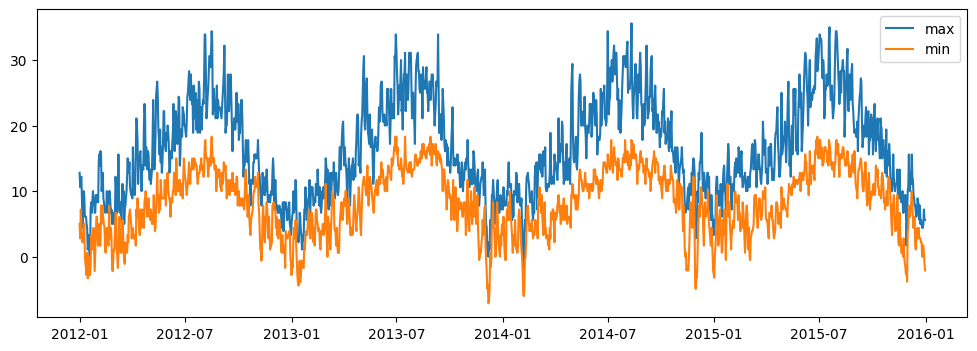

In [ ]:
fig, ax=plt.subplots(figsize=(12, 4))

ax.plot(weather.index, weather['temp_max'], label='max')
ax.plot(weather.index, weather['temp_min'], label='min')

plt.legend()
plt.show()

### Značky a čáry v grafu

V níže uvedeném příkladu uvažujme pouze dílčí data pro 20 po sobě jdoucích hodnot teploty. Všimněte si, že k lepší čitelnosti může přispět i rotace značek na ose X.

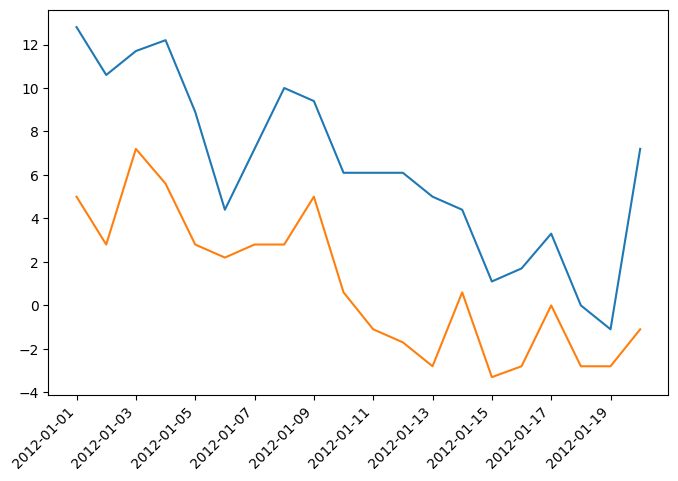

In [ ]:
n = 20

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    weather.index[:n],
    weather['temp_max'][:n],
)

ax.plot(
    weather.index[:n],
    weather['temp_min'][:n],
)

plt.xticks(rotation=45, ha="right")
plt.show()

Zatím jsme používali výchozí argumenty, ale to, jak bude vytvořený graf vypadat, můžete výrazně ovlivnit!

V matplotlibu se **<font color='##13e5e1'>značky a čáry používají k reprezentaci datových bodů a jejich propojení</font>** v grafu:
* **<font color='darkorange'>značky</font>** jsou symboly nebo tvary, které představují jednotlivé datové body na grafu.
 * mohou být použity ke zvýraznění polohy datových hodnot.
 * existuje celá řada možností značek, například tečky, čtverce, trojúhelníky a další.
 * možnosti přizpůsobení značek zahrnují size, color, edge color, a transparency
* **<font color='darkorange'>čáry</font>** slouží ke spojení datových bodů v grafu a vytvářejí spojité čáry nebo křivky - pomáhají vizualizovat trendy a vztahy mezi datovými body.
 * běžné styly čar zahrnují plné čáry, přerušované čáry, tečkované čáry a další.
 * můžete přizpůsobit barvy, šířky a průhlednost čar pomocí parametrů, jako je color, linewidth, a alpha

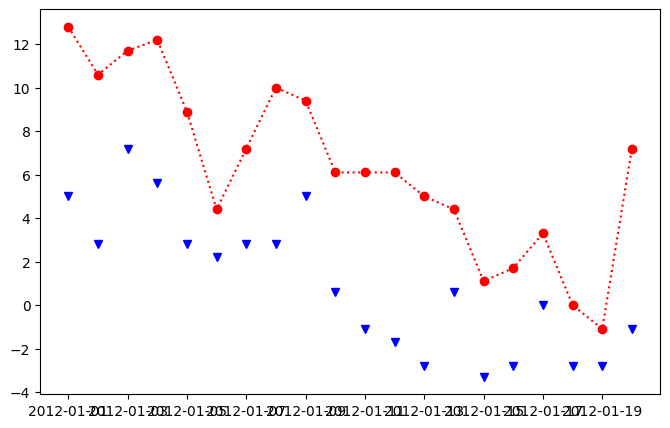

In [ ]:
n = 20

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    weather.index[:n],
    weather['temp_max'][:n],
    marker='o',
    linestyle=':',
    color='r'
)

ax.plot(    weather.index[:n],    weather['temp_min'][:n],    marker='v',    linestyle='None',    color='b')

plt.xticks(rotation=45)
plt.show()

### **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>PRO VÁS</font>**

Vytvořte graf:
* vyberte posledních 30 pozorování z kolekce `weather`.
* nastavte velikost grafu
* vytvořte čárový graf pro proměnné `wind` a `precipitation`.
* změňte typ značky, barvu a typ čáry
* přidejte legendu s popisem čáry

<img src="https://drive.google.com/uc?export=view&id=1O6FIgYMRe843hNtFk4sq3aO8H-a51_yZ" alt="Matplotlib: úkol pro vás" title="Matplotlib: task for you" align="center" width="500px" hspace="30px" vspace="10px"/>

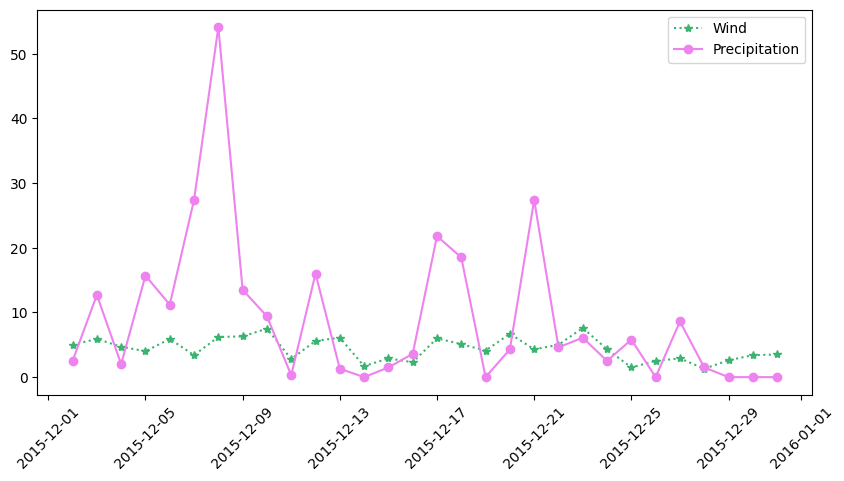

In [ ]:
n = 30 #30 pozorovani

fig, ax = plt.subplots(figsize=(10, 5))

#wind
ax.plot(
    weather.index[-n:],
    weather['wind'][-n:],
    marker='*',
    linestyle=':',
    color='#3cb371',
    label='Wind'
)

#precipitation
ax.plot(
    weather.index[-n:],
    weather['precipitation'][-n:],
    marker='o',
    #linestyle='-',
    color='#ee82ee',
    label='Precipitation'
)
plt.xticks(rotation=45)
plt.legend()

plt.show()

### Nadpis a popisky os

Chcete-li přidat **<font color='##13e5e1'>nadpis a popisky na osy X a Y</font>** do grafu v matplotlib, můžete použít následující kroky:
* nastavte titulek grafu pomocí funkce `plt.title()`. Této funkci předejte požadovaný název jako stringový argument.
* nastavte popisek X pomocí funkce `plt.xlabel()`. Této funkci předejte požadovaný text popisku jako stringový argument. Pro popisek Y použijte funkci `plt.ylabel()`.

V případě potřeby můžete vzhled nadpisu a popisku os dále přizpůsobit pomocí dalších volitelných parametrů, které jsou k dispozici v příslušných funkcích. Tyto parametry umožňují upravit velikost písma, styl písma, barvu, zarovnání a další vlastnosti nadpisu a popisků os.

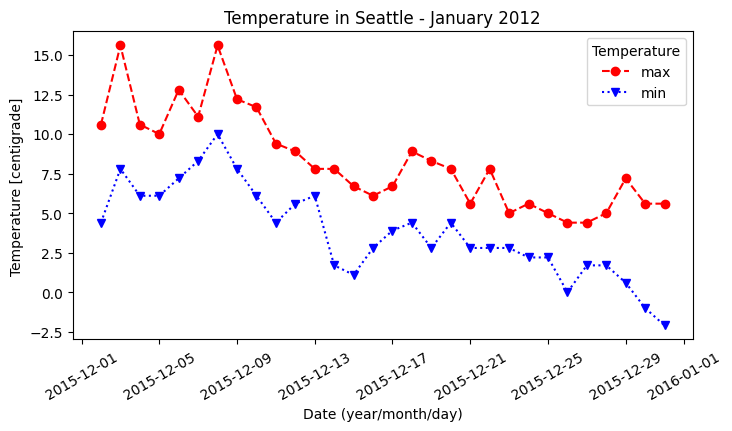

In [ ]:
n=30

fig,ax = plt.subplots(figsize=(8, 4))

ax.plot(
    weather.index[-n:],
    weather['temp_max'][-n:],
    marker='o',
    linestyle='--',
    color='r',
    label='max'
)

ax.plot(
    weather.index[-n:],
    weather['temp_min'][-n:],
    marker='v',
    linestyle='dotted',
    color='b',
    label='min'
)

ax.set_title('Temperature in Seattle - January 2012')  # plt.title()
ax.set_xlabel('Date (year/month/day)')  # plt.xlabel()
ax.set_ylabel('Temperature [centigrade]')  # plt.ylabel()
#ax.xaxis.set_tick_params(rotation=90)  # eq. to ax.xticks()

ax.legend(title='Temperature')
plt.xticks(rotation=30)
plt.show()

### **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>PRO VÁS</font>**

Upravte poslední graf:
* změňte parametry marker, linestyle a color
* změňte natočení značek na ose X
* pro osu X, osu Y a nadpis definujte písmo (type, color, size).

<img src="https://drive.google.com/uc?export=view&id=1OU1Bc3K8A_lqIBvlhLRLqM1Pt_ZLtfd1" alt="Matplotlib: úkol pro vás" title="Matplotlib: task for you" align="center" width="500px" hspace="30px" vspace="10px"/>


<img src="https://drive.google.com/uc?export=view&id=141XOz6N4nk8Ru1sAl7vOsAToCLrSFCAX" alt="SDA logo" width="150" align='right'/>
<br>

## Počasí v Austinu

In [ ]:
url='https://raw.githubusercontent.com/matzim95/ML-datasets/master/austin_weather.csv'

austin_weather = pd.read_csv(url, parse_dates=True, index_col='Date')
austin_weather.head()

,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,SeaLevelPressureHighInches,SeaLevelPressureAvgInches,SeaLevelPressureLowInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches,Events
Date,,,,,,,,,,,,,,,,,,,,
2013-12-21,74,60,45,67,49,43,93,75,57,29.86,29.68,29.59,10,7,2,20,4,31,0.46,"Rain , Thunderstorm"
2013-12-22,56,48,39,43,36,28,93,68,43,30.41,30.13,29.87,10,10,5,16,6,25,0,
2013-12-23,58,45,32,31,27,23,76,52,27,30.56,30.49,30.41,10,10,10,8,3,12,0,
2013-12-24,61,46,31,36,28,21,89,56,22,30.56,30.45,30.3,10,10,7,12,4,20,0,
2013-12-25,58,50,41,44,40,36,86,71,56,30.41,30.33,30.27,10,10,7,10,2,16,T,


In [ ]:
austin_weather.dtypes

,0
TempHighF,int64
TempAvgF,int64
TempLowF,int64
DewPointHighF,object
DewPointAvgF,object
DewPointLowF,object
HumidityHighPercent,object
HumidityAvgPercent,object
HumidityLowPercent,object
SeaLevelPressureHighInches,object


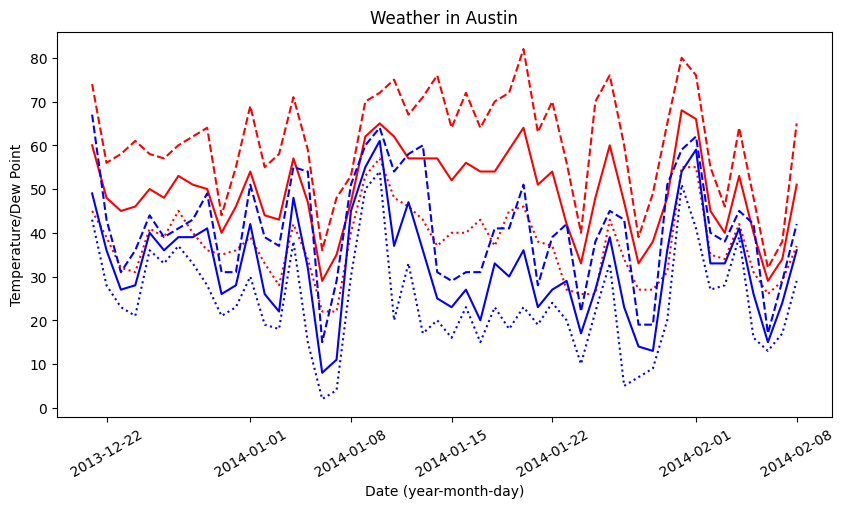

In [ ]:
n = 50
fig, ax=plt.subplots(figsize=(10, 5))

ax.plot(austin_weather.index[:n], austin_weather['TempAvgF'][:n], color='r')
ax.plot(austin_weather.index[:n], austin_weather['TempHighF'][:n], color='r', linestyle='--')
ax.plot(austin_weather.index[:n], austin_weather['TempLowF'][:n], color='r', linestyle='dotted')

ax.plot(austin_weather.index[:n], austin_weather['DewPointAvgF'][:n].astype(float), color='b')
ax.plot(austin_weather.index[:n], austin_weather['DewPointHighF'][:n].astype(float), color='b', linestyle='--')
ax.plot(austin_weather.index[:n], austin_weather['DewPointLowF'][:n].astype(float), color='b', linestyle='dotted')

plt.xlabel('Date (year-month-day)')
plt.ylabel('Temperature/Dew Point')
plt.title('Weather in Austin')
plt.xticks(rotation=30)
plt.show()

### Dílčí grafy (Subplots)

Dílčí grafy v matplotlibu umožňují **<font color='##13e5e1'>vytvořit více grafů v rámci jednoho obrázku</font>**. Pomocí funkce `plt.subplots()` můžete určit rozložení dílčích grafů, přistupovat ke každému dílčímu grafu zvlášť, vykreslovat data na každém dílčím grafu a přizpůsobovat je. Dílčí grafy jsou užitečné pro porovnávání souborů dat nebo pro zobrazení různých aspektů stejných dat.

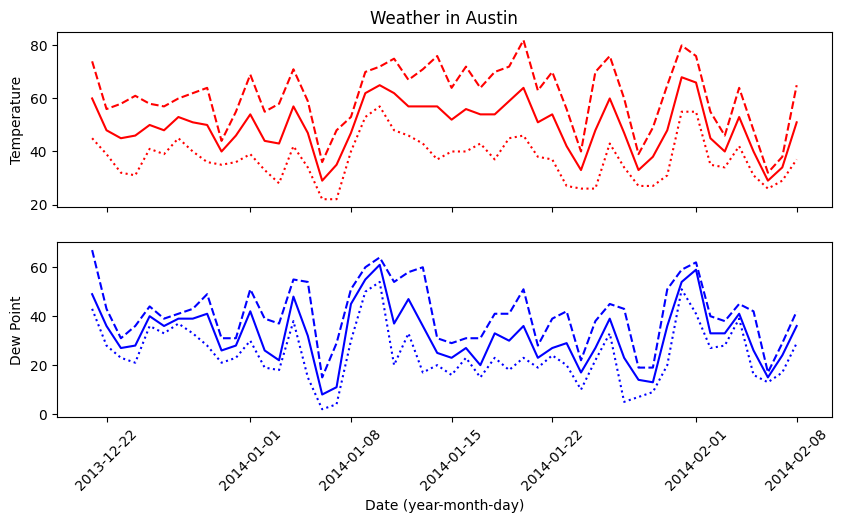

In [ ]:
n = 50
fig, ax = plt.subplots(2, 1,sharex=True, figsize=(10, 5))

ax[0].plot(austin_weather.index[:n], austin_weather['TempAvgF'][:n], color='r')
ax[0].plot(austin_weather.index[:n], austin_weather['TempHighF'][:n], color='r', linestyle='--')
ax[0].plot(austin_weather.index[:n], austin_weather['TempLowF'][:n], color='r', linestyle='dotted')


ax[1].plot(austin_weather.index[:n], austin_weather['DewPointAvgF'][:n].astype(float), color='b')
ax[1].plot(austin_weather.index[:n], austin_weather['DewPointHighF'][:n].astype(float), color='b', linestyle='--')
ax[1].plot(austin_weather.index[:n], austin_weather['DewPointLowF'][:n].astype(float), color='b', linestyle='dotted')

ax[1].set_xlabel('Date (year-month-day)')
ax[0].set_ylabel('Temperature')
ax[1].set_ylabel('Dew Point')

ax[0].set_title('Weather in Austin')
ax[1].xaxis.set_tick_params(rotation=45)
plt.show()

### Textové anotace

Textové anotace v matplotlib umožňují **<font color='##13e5e1'>přidávat do grafů textové informace</font>**. Pomocí funkce `plt.text()` můžete určit obsah textu a jeho pozici na grafu. Funkce `plt.annotate()` navíc poskytuje další možnosti pro anotování konkrétních datových bodů šipkami a textem. Textové anotace pomáhají poskytnout kontext a vysvětlení v rámci grafů.

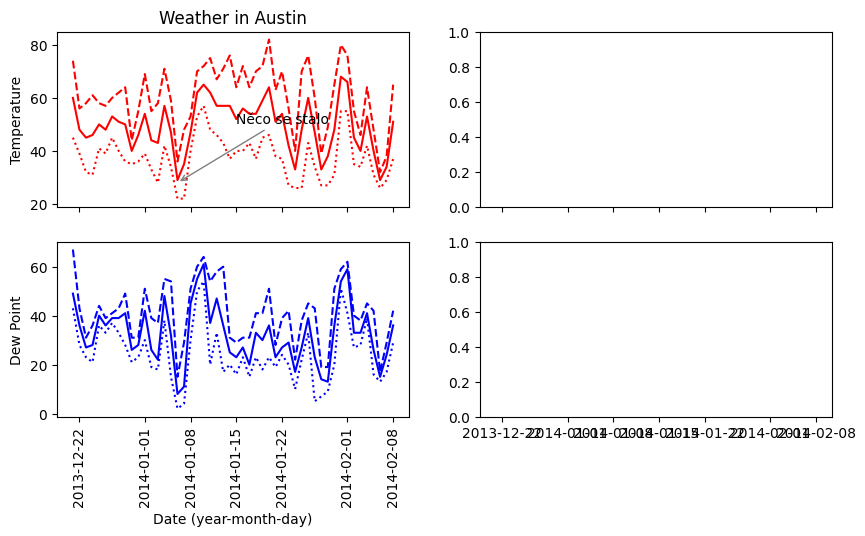

In [ ]:
n=50
fig, ax=plt.subplots(2, 2, sharex=True, figsize=(10, 5))

ax[0][0].plot(austin_weather.index[:n], austin_weather['TempAvgF'][:n], color='r')
ax[0][0].plot(austin_weather.index[:n], austin_weather['TempHighF'][:n], color='r', linestyle='--')
ax[0][0].plot(austin_weather.index[:n], austin_weather['TempLowF'][:n], color='r', linestyle='dotted')


ax[1][0].plot(austin_weather.index[:n], austin_weather['DewPointAvgF'][:n].astype(float), color='b')
ax[1][0].plot(austin_weather.index[:n], austin_weather['DewPointHighF'][:n].astype(float), color='b', linestyle='--')
ax[1][0].plot(austin_weather.index[:n], austin_weather['DewPointLowF'][:n].astype(float), color='b', linestyle='dotted')

ax[1][0].set_xlabel('Date (year-month-day)')
ax[0][0].set_ylabel('Temperature')
ax[1][0].set_ylabel('Dew Point')

ax[0][0].set_title('Weather in Austin')
ax[1][0].xaxis.set_tick_params(rotation=90)

ax[0][0].annotate(
    'Něco se stalo',
    xy=[pd.Timestamp('2014-01-06'),28],
    xytext=(pd.Timestamp('2014-01-15'),50.5),
    arrowprops={'arrowstyle':'->','color':'gray'}
)

ax[1][1].annotate(
    'Něco se stalo',
    xy=[pd.Timestamp('2014-01-06'),28],
    xytext=(pd.Timestamp('2014-01-15'),50.5),
    arrowprops={'arrowstyle':'->','color':'gray'}
)
plt.show()

### **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>PRO VÁS</font>**

Vytvořte graf založený na souboru dat o počasí pro Austin:
* pro čtvrté čtvrtletí roku 2015
* zahrňte do grafu teplotu (průměrná, vysoká, nízká), vlhkost (průměrná, vysoká, nízká) a vítr (průměrný, vysoký, nárazový)
* přidejte do grafu anotaci, tj. označte, kdy byla ve zkoumaném období nejsilnější větrná bouře

<img src="https://drive.google.com/uc?export=view&id=1G3uFQGLK2hQ7oZh-1xEmfqgwFRwy5ZSI" alt="Matplotlib: úkol pro vás" title="Matplotlib: task for you" align="center" width="650px" hspace="30px" vspace="10px"/>

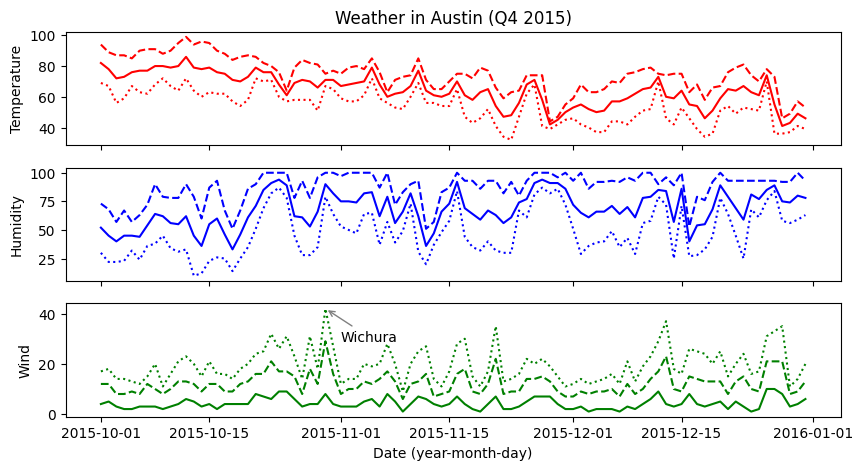

In [ ]:
n = austin_weather.loc["2015-10-01":"2015-12-31"]

fig, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 5))


ax[0].plot(n.index, n['TempAvgF'], color='r')
ax[0].plot(n.index, n['TempHighF'], color='r', linestyle='--')
ax[0].plot(n.index, n['TempLowF'], color='r', linestyle='dotted')
ax[1].plot(n.index, n['HumidityAvgPercent'].astype(float), color='b')
ax[1].plot(n.index, n['HumidityHighPercent'].astype(float), color='b', linestyle='--')
ax[1].plot(n.index, n['HumidityLowPercent'].astype(float), color='b', linestyle='dotted')
ax[2].plot(n.index, n['WindAvgMPH'].astype(float), color='g')
ax[2].plot(n.index, n['WindHighMPH'].astype(float), color='g', linestyle='--')
ax[2].plot(n.index, n['WindGustMPH'].astype(float), color='g', linestyle='dotted')
ax[2].set_xlabel('Date (year-month-day)')
ax[0].set_ylabel('Temperature')
ax[1].set_ylabel('Humidity')
ax[2].set_ylabel('Wind')
ax[0].set_title('Weather in Austin (Q4 2015)')
ax[1].xaxis.set_tick_params(rotation=90)

ax[2].annotate(
    'Wichura',
    xy=(pd.Timestamp('2015-10-30'), 42),
    xytext=(pd.Timestamp('2015-11-01'),29),
    arrowprops={'arrowstyle': '->', 'color': 'gray'}
)

plt.show()

<img src="https://drive.google.com/uc?export=view&id=141XOz6N4nk8Ru1sAl7vOsAToCLrSFCAX" alt="SDA logo" width="150" align='right'/>
<br>

## Oxid uhličitý ($CO_2$)

In [ ]:
url = 'https://raw.githubusercontent.com/matzim95/ML-datasets/master/co2.csv'

co2 = pd.read_csv(url, parse_dates=True, index_col='Date')
co2

,Decimal Date,Average,Interpolated,Trend,Number of Days
Date,,,,,
1958-03-01,1958.208,315.71,315.71,314.62,-1
1958-04-01,1958.292,317.45,317.45,315.29,-1
1958-05-01,1958.375,317.50,317.50,314.71,-1
1958-06-01,1958.458,-99.99,317.10,314.85,-1
1958-07-01,1958.542,315.86,315.86,314.98,-1
...,...,...,...,...,...
2018-05-01,2018.375,411.24,411.24,407.91,24
2018-06-01,2018.458,410.79,410.79,408.49,29
2018-07-01,2018.542,408.71,408.71,408.32,27


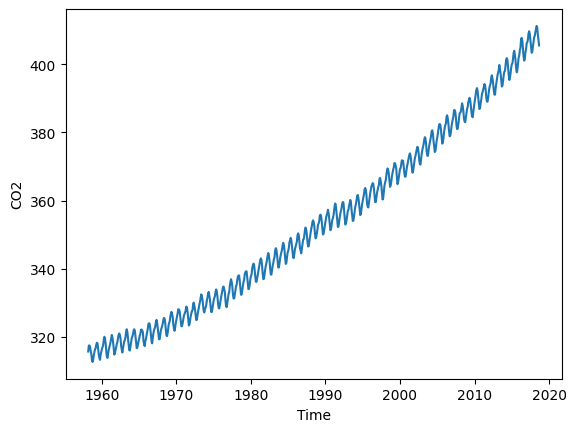

In [ ]:
fig,ax=plt.subplots()

ax.plot(
    co2.index,
    co2.Interpolated
)

ax.set_xlabel('Time')
ax.set_ylabel('CO2')
plt.show()

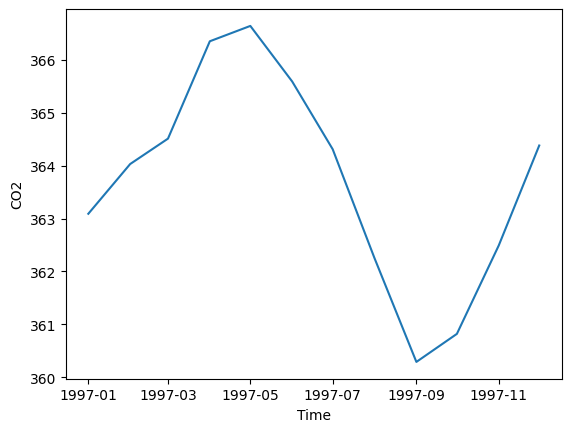

In [ ]:
rok_97 = co2["1997":"1997"]

fig, ax=plt.subplots()

ax.plot(
    rok_97.index,
    rok_97.Interpolated
)

ax.set_xlabel('Time')
ax.set_ylabel('CO2')
plt.show()

In [ ]:
url='https://raw.githubusercontent.com/matzim95/ML-datasets/master/temperature.csv'

temperature = pd.read_csv(url, parse_dates=True, index_col='dt')
temperature.index.names = ['Date']
temperature

,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
Date,,,,,,
1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W
1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W
1849-03-01,28.101,1.612,Abidjan,Côte D'Ivoire,5.63N,3.23W
1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W
1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W
...,...,...,...,...,...,...
2013-05-01,18.979,0.807,Xian,China,34.56N,108.97E
2013-06-01,23.522,0.647,Xian,China,34.56N,108.97E
2013-07-01,25.251,1.042,Xian,China,34.56N,108.97E


In [ ]:
paris = temperature[temperature.City == 'Paris']
paris

,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
Date,,,,,,
1743-11-01,7.648,1.749,Paris,France,49.03N,2.45E
1743-12-01,NaN,NaN,Paris,France,49.03N,2.45E
1744-01-01,NaN,NaN,Paris,France,49.03N,2.45E
1744-02-01,NaN,NaN,Paris,France,49.03N,2.45E
1744-03-01,NaN,NaN,Paris,France,49.03N,2.45E
...,...,...,...,...,...,...
2013-05-01,11.703,0.282,Paris,France,49.03N,2.45E
2013-06-01,16.340,0.271,Paris,France,49.03N,2.45E
2013-07-01,21.186,0.381,Paris,France,49.03N,2.45E


In [ ]:
merged = pd.merge(co2, paris, how='inner', on='Date')
merged

,Decimal Date,Average,Interpolated,Trend,Number of Days,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
Date,,,,,,,,,,,
1958-03-01,1958.208,315.71,315.71,314.62,-1,4.387,0.182,Paris,France,49.03N,2.45E
1958-04-01,1958.292,317.45,317.45,315.29,-1,7.835,0.219,Paris,France,49.03N,2.45E
1958-05-01,1958.375,317.50,317.50,314.71,-1,14.120,0.402,Paris,France,49.03N,2.45E
1958-06-01,1958.458,-99.99,317.10,314.85,-1,15.723,0.388,Paris,France,49.03N,2.45E
1958-07-01,1958.542,315.86,315.86,314.98,-1,18.091,0.420,Paris,France,49.03N,2.45E
...,...,...,...,...,...,...,...,...,...,...,...
2013-05-01,2013.375,399.78,399.78,396.40,28,11.703,0.282,Paris,France,49.03N,2.45E
2013-06-01,2013.458,398.61,398.61,396.28,26,16.340,0.271,Paris,France,49.03N,2.45E
2013-07-01,2013.542,397.32,397.32,396.92,21,21.186,0.381,Paris,France,49.03N,2.45E


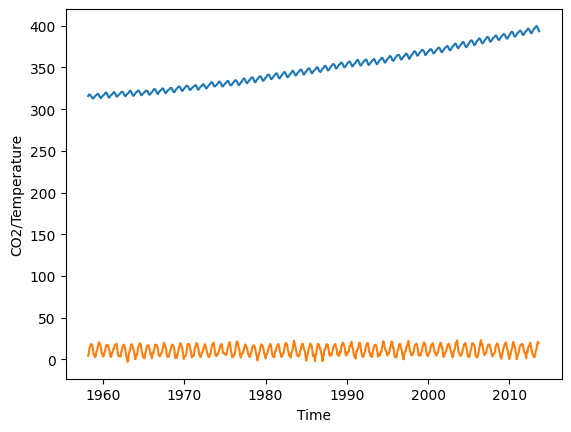

In [ ]:
fig, ax = plt.subplots()

ax.plot(merged.index, merged.Interpolated)
ax.plot(merged.index, merged.AverageTemperature)

ax.set_xlabel('Time')
ax.set_ylabel('CO2/Temperature')
plt.show()

### Dvě odlišné stupnice na ose Y

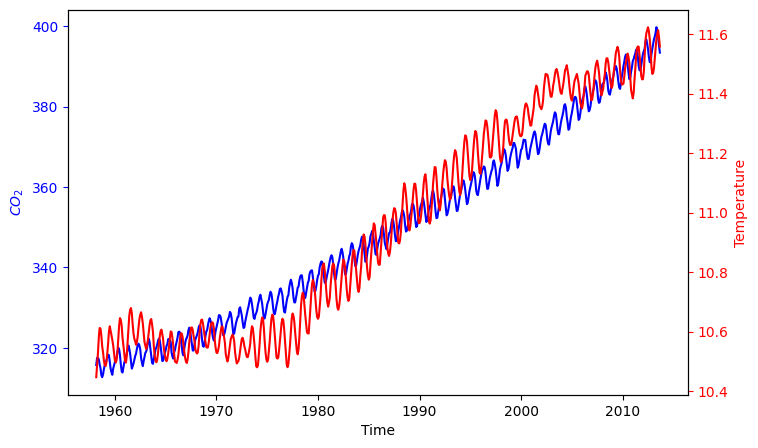

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    merged.index,
    merged.Interpolated,color='b'
)
ax.set_xlabel('Time')
ax.set_ylabel('$CO_2$', color='b')
ax.tick_params('y', color='b', labelcolor='b')

# clone Y-axis (leave X-axis as shared one)
ax2 = ax.twinx()
ax2.plot(
    merged.index,
    merged.AverageTemperature.rolling(window=365,center=True,min_periods=0).mean(),
    color='r'
)
ax2.set_ylabel('Temperature', color='r')
ax2.tick_params('y', color='r', labelcolor='r')

plt.show()

### Vytváření grafů pomocí vlastních předdefinovaných funkcí

In [ ]:
def plot_timeseries(axis, x, y, color, xlabel, ylabel):
  axis.plot(x, y, color)
  axis.set_xlabel(xlabel)
  axis.set_ylabel(ylabel, color=color)
  axis.tick_params('y', colors=color, labelcolor=color)


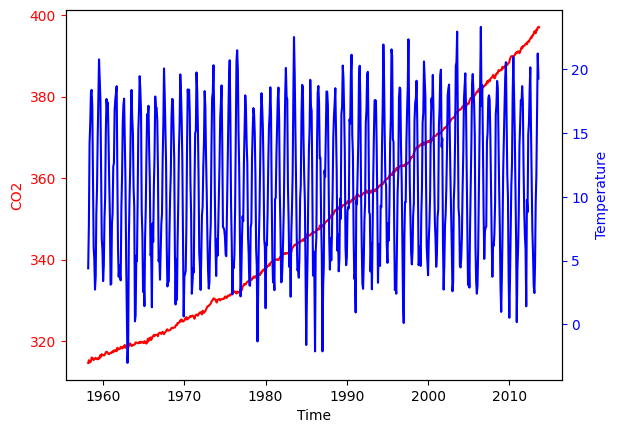

In [ ]:
fig,ax = plt.subplots()

plot_timeseries(
    axis=ax,
    x=merged.index,
    y=merged.Trend,
    color='r',
    xlabel='Time',
    ylabel='CO2'
)

ax2=ax.twinx()
plot_timeseries(
    axis=ax2,
    x=merged.index,
    y=merged.AverageTemperature,
    color='b',
    xlabel='Time',
    ylabel='Temperature'
)

### **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>PRO VÁS</font>**

Na základě dat o počasí ze Seattlu (`weather.csv`) vytvořte graf zobrazující srážky a sílu větru v roce 2014.

Dbejte na estetickou stránku grafu (popisek grafu, osy, formát písma, případné rozdělení na 2 dílčí grafy, formát značek).

<img src="https://drive.google.com/uc?export=view&id=1JKuq1bjzfEFJ2ZQIwyIAzp_Y9nIJKkAf" alt="Matplotlib: úkol pro vás" title="Matplotlib: task for you" align="center" width="750px" hspace="30px" vspace="10px"/>

*Nápověda: použijte `plt.tight_layout()`*

<img src="https://drive.google.com/uc?export=view&id=141XOz6N4nk8Ru1sAl7vOsAToCLrSFCAX" alt="SDA logo" width="150" align='right'/>
<br>

## Sloupcové grafy

Sloupcové grafy jsou dalším oblíbeným typem vizualizace, který se používá k **<font color='##13e5e1'>zobrazení kategoriálních dat pomocí obdélníkových sloupců</font>**.

Chcete-li vytvořit sloupcový graf, použijte funkci `plt.bar()`. Zadejte kategoriální hodnoty jako souřadnice osy X a odpovídající číselné hodnoty jako výšku sloupců.

Sloupcové grafy se běžně používají k zobrazení výsledků průzkumů, údajů o prodeji nebo jakýchkoli údajů s odlišnými kategoriemi. Matplotlib poskytuje flexibilitu při přizpůsobování vzhledu sloupcových grafů, což umožňuje vytvářet vizuálně atraktivní a informativní vizualizace.

In [ ]:
url='https://raw.githubusercontent.com/matzim95/ML-datasets/master/population.csv'

population = pd.read_csv(url, index_col='City')
population[population.index=="WARSZAWA"]

,Country or Area,Year,Area,Sex,City type,Record Type,Reliability,Source Year,Value,Value Footnotes
City,,,,,,,,,,
WARSZAWA,Poland,2017,Total,Both Sexes,City proper,Estimate - de jure,"Final figure, complete",2018,1754511,"1,2"
WARSZAWA,Poland,2017,Total,Male,City proper,Estimate - de jure,"Final figure, complete",2018,806730,"1,2"
WARSZAWA,Poland,2017,Total,Female,City proper,Estimate - de jure,"Final figure, complete",2018,947781,"1,2"


In [ ]:
population_by_sex = population.groupby('Sex')
both, female, male = [population_by_sex.get_group(x) for x in population_by_sex.groups]


In [ ]:
female = population[population.Sex == 'Female']
male = population[population.Sex == 'Male']
both = population[population.Sex == 'Both Sexes']

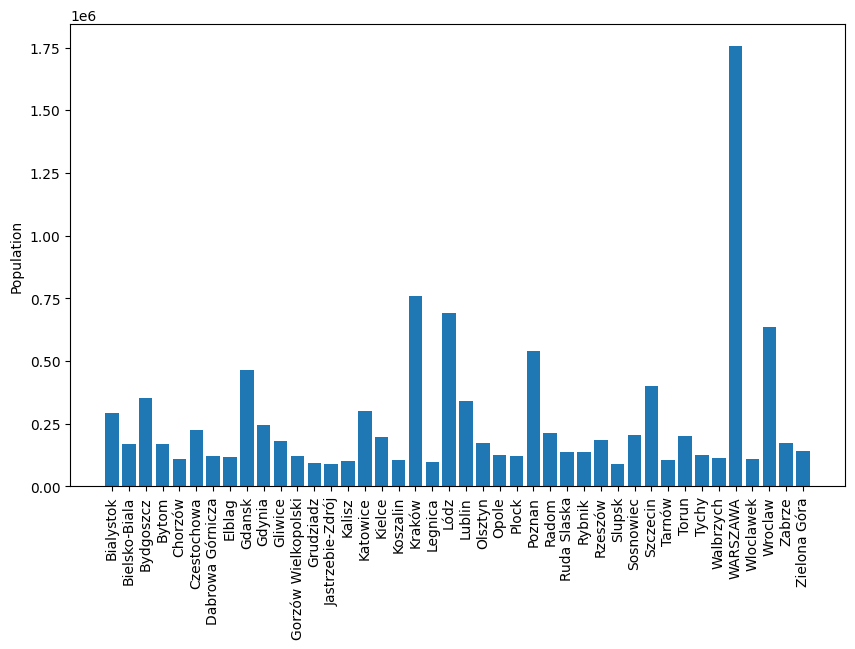

In [ ]:
# all together
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(both.index,both['Value'])

ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('Population')
plt.show()

Pokud máte **<font color='##13e5e1'>více kategorií k porovnání</font>**, můžete vykreslit seskupené nebo skládané sloupcové grafy zadáním příslušných hodnot parametrům `width` a `bottom` funkce `plt.bar()`.

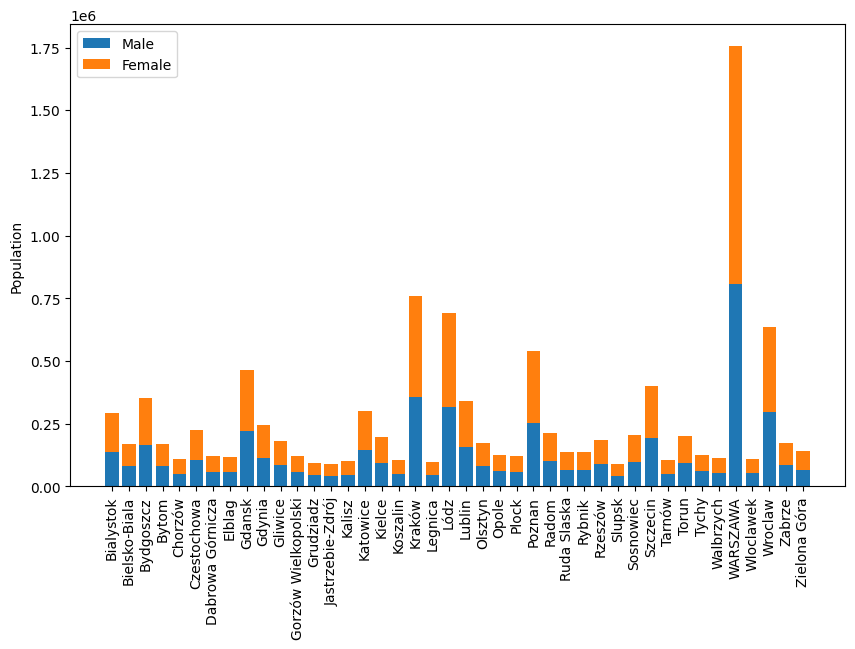

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(male.index, male['Value'], label='Male')
ax.bar(female.index, female['Value'], label='Female', bottom=male['Value'])

ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('Population')

ax.legend()
plt.show()

### **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>PRO VÁS</font>**

Vytvořte sloupcový graf s rozložením mužů a žen v polských městech:
* na ose X vyznačte města
* na ose Y procentuální podíl daného pohlaví na celé populaci

Použijte sloupcové grafy (pro dané město, jeden sloupec nad druhým).

Přidejte také vodorovnou čáru ve výšce 0,5.

<img src="https://drive.google.com/uc?export=view&id=1XMwrPnzmKtbiG98NaO7Z3KgSxcjy9mKW" alt="Matplotlib: task for you" title="Matplotlib: task for you" align="center" width="750px" hspace="30px" vspace="10px"/>

*Nápověda: použijte `plt.axhline()`*

<img src="https://drive.google.com/uc?export=view&id=141XOz6N4nk8Ru1sAl7vOsAToCLrSFCAX" alt="SDA logo" width="150" align='right'/>
<br>

## Histogramy

Histogram je **<font color='##13e5e1'>grafické znázornění rozložení souboru dat</font>**. Poskytuje vizuální shrnutí základního rozdělení četnosti nebo pravděpodobnosti souboru spojitých nebo diskrétních dat.

Histogramy se běžně používají při analýze dat a  explorativní vizualizaci dat. Umožňují rychlé posouzení rozložení dat a mohou zvýraznit důležité rysy, jako jsou odlehlé hodnoty nebo tendence ke shlukování. Histogramy jsou užitečné zejména při analýze spojitých číselných dat, jako jsou výsledky zkoušek, hustota obyvatelstva nebo měření srážek.

In [ ]:
url = 'https://raw.githubusercontent.com/matzim95/ML-datasets/master/olympic.csv'

medals = pd.read_csv(url, index_col='Year')
medals.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Season,City,Sport,Event,Medal
Year,,,,,,,,,,,,,,
1992,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
2012,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
1920,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,Summer,Antwerpen,Football,Football Men's Football,NaN
1900,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
1988,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [ ]:
def get_dict_with_grouped_data(df, column):
  groupby = df.groupby(column)
  return {x: groupby.get_group(x) for x in groupby.groups}

In [ ]:
all_sports = get_dict_with_grouped_data(medals, 'Sport')

all_sports['Basketball']

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Season,City,Sport,Event,Medal
Year,,,,,,,,,,,,,,
1992,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
2008,69,Tamara Abalde Daz,F,19.0,185.0,72.0,Spain,ESP,2008 Summer,Summer,Beijing,Basketball,Basketball Women's Basketball,NaN
1952,124,Youssef Mohamed Abbas,M,31.0,NaN,NaN,Egypt,EGY,1952 Summer,Summer,Helsinki,Basketball,Basketball Men's Basketball,NaN
2000,136,Alessandro Abbio,M,29.0,195.0,85.0,Italy,ITA,2000 Summer,Summer,Sydney,Basketball,Basketball Men's Basketball,NaN
1972,192,Ahmed El-Sayed Abdel Hamid Mobarak,M,25.0,189.0,85.0,Egypt,EGY,1972 Summer,Summer,Munich,Basketball,Basketball Men's Basketball,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004,135401,Eurelijus ukauskas,M,30.0,218.0,115.0,Lithuania,LTU,2004 Summer,Summer,Athina,Basketball,Basketball Men's Basketball,NaN
1996,135402,Mindaugas ukauskas,M,20.0,201.0,100.0,Lithuania,LTU,1996 Summer,Summer,Atlanta,Basketball,Basketball Men's Basketball,Bronze
2004,135402,Mindaugas ukauskas,M,28.0,201.0,100.0,Lithuania,LTU,2004 Summer,Summer,Athina,Basketball,Basketball Men's Basketball,NaN


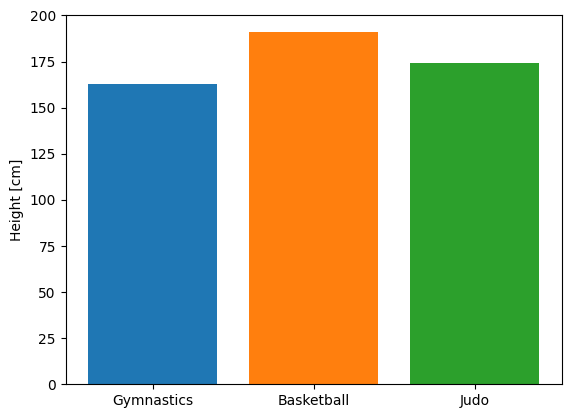

In [ ]:
fig,ax = plt.subplots()

ax.bar('Gymnastics', all_sports['Gymnastics']['Height'].mean())
ax.bar('Basketball', all_sports['Basketball']['Height'].mean())
ax.bar('Judo',all_sports['Judo']['Height'].mean())

ax.set_ylabel('Height [cm]')
plt.show()

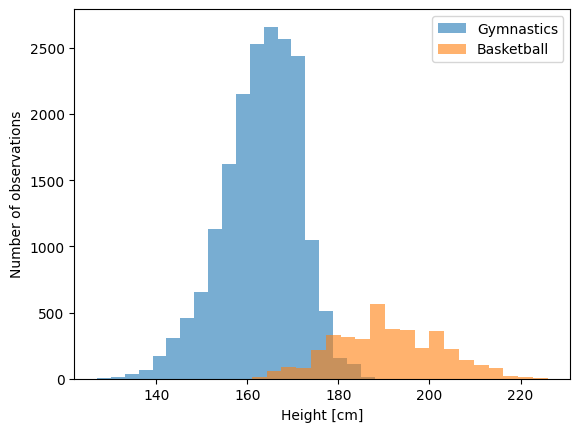

In [ ]:
fig,ax=plt.subplots()

ax.hist(
    all_sports['Gymnastics']['Height'],
    label='Gymnastics',
    bins=20,
    alpha=0.6
)

ax.hist(
    all_sports['Basketball']['Height'],
    label='Basketball',
    bins=20,
    alpha=0.6
)


ax.set_xlabel('Height [cm]')
ax.set_ylabel('Number of observations')
ax.legend()
plt.show()

### **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>PRO VÁS</font>**

Vytvořte graf s histogramem růstu hráčů pro 3 sporty:
* experimentujte s parametrem `bins` (počet sloupců) a vyberte si ten nejlepší podle vás.
* změňte vzhled grafu
 * přidejte název
 * změňte písmo nadpisů
 * případně změňte orientaci grafu
 * upravte vzhled sloupců
 * atd.

<img src="https://drive.google.com/uc?export=view&id=1xZ9uzqBfnF-L1YgTnwpWuFbLLs-CJHxs" alt="Matplotlib: task for you" title="Matplotlib: task for you" align="center" width="750px" hspace="30px" vspace="10px"/>

## Chybové úsečky (ve sloupcových a čárových grafech)

Chybové úsečky se používají k **<font color='##13e5e1'>zobrazení nejistoty nebo variability</font>** spojené s datovými body. Vizuálně znázorňují intervaly spolehlivosti, směrodatné chyby nebo směrodatné odchylky kolem průměrných hodnot nebo mediánu.

Zde je návod, jak přidat chybové úsečky do sloupcového/čárového grafu v matplotlibu:

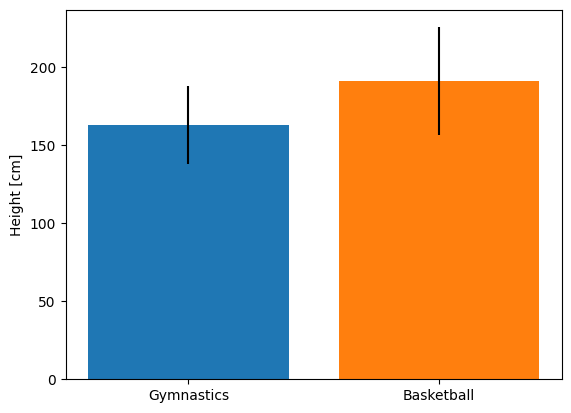

In [ ]:
fig, ax = plt.subplots()

ax.bar(
    'Gymnastics',
    all_sports['Gymnastics']['Height'].mean(),
    yerr=all_sports['Gymnastics']['Height'].std()*3
)
ax.bar(
    'Basketball',
    all_sports['Basketball']['Height'].mean(),
    yerr=all_sports['Basketball']['Height'].std()*3
)

ax.set_ylabel('Height [cm]')
plt.show()

In [ ]:
try:
    display(austin_weather.head())
except NameError:
    url='https://raw.githubusercontent.com/matzim95/ML-datasets/master/austin_weather.csv'

    austin_weather = pd.read_csv(url, parse_dates=True, index_col='Date')
    display(austin_weather.head())

,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,SeaLevelPressureHighInches,SeaLevelPressureAvgInches,SeaLevelPressureLowInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches,Events
Date,,,,,,,,,,,,,,,,,,,,
2013-12-21,74,60,45,67,49,43,93,75,57,29.86,29.68,29.59,10,7,2,20,4,31,0.46,"Rain , Thunderstorm"
2013-12-22,56,48,39,43,36,28,93,68,43,30.41,30.13,29.87,10,10,5,16,6,25,0,
2013-12-23,58,45,32,31,27,23,76,52,27,30.56,30.49,30.41,10,10,10,8,3,12,0,
2013-12-24,61,46,31,36,28,21,89,56,22,30.56,30.45,30.3,10,10,7,12,4,20,0,
2013-12-25,58,50,41,44,40,36,86,71,56,30.41,30.33,30.27,10,10,7,10,2,16,T,


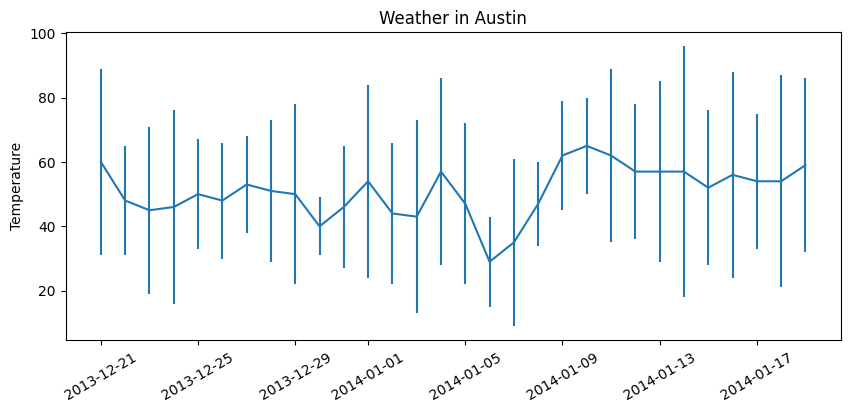

In [ ]:
n = 30
fig, ax = plt.subplots(figsize=(10, 4))

ax.errorbar(
    austin_weather.index[:n],
    austin_weather['TempAvgF'][:n],
    yerr=(austin_weather['TempHighF'][:n] - austin_weather['TempLowF'][:n])
)

ax.set_ylabel('Temperature')
ax.set_title('Weather in Austin')
ax.xaxis.set_tick_params(rotation=30)
plt.show()

## Krabicový graf (Box plot)

Krabicový graf, známý také v angličtině pod názvem box-and-whisker (krabice a vousy), je dalším **<font color='##13e5e1'>grafickým znázorněním rozdělení</font>** souboru dat. Poskytuje souhrn klíčových statistických měr, včetně mediánu, kvartilů a potenciálních odlehlých hodnot.

Zde je návod, jak vytvořit krabicový graf v matplotlibu:


In [ ]:
weather.head()

,precipitation,temp_max,temp_min,wind,weather
date,,,,,
2012-01-01,0.0,12.8,5.0,4.7,drizzle
2012-01-02,10.9,10.6,2.8,4.5,rain
2012-01-03,0.8,11.7,7.2,2.3,rain
2012-01-04,20.3,12.2,5.6,4.7,rain
2012-01-05,1.3,8.9,2.8,6.1,rain


In [ ]:
print(weather.columns)

Index(['precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')


In [ ]:
print(weather['precipitation'].loc(['drizzle']))

TypeError: unhashable type: 'list'

KeyError: 'weather'

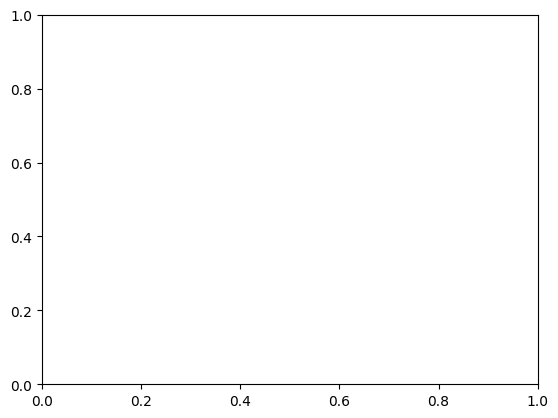

In [ ]:
fig, ax = plt.subplots()

ax.boxplot([
    weather.loc['weather']['drizzle'].dropna(),
    weather.loc['precipitation']['rain'].dropna(),
    weather.loc['precipitation']['sun'].dropna(),
    weather.loc['precipitation']['fog'].dropna(),
])


ax.set_ylabel('Height [cm]')
plt.show()

## Bodový graf (korelační diagram)

Bodový graf je typ **<font color='##13e5e1'>grafu, který zobrazuje vztah mezi dvěma číselnými proměnnými</font>**. Jednotlivé datové body znázorňuje jako body na dvourozměrném souřadnicovém systému.

Zde je příklad, jak vytvořit bodový graf:

In [ ]:
try:
    merged.head()
except NameError:
    url = 'https://raw.githubusercontent.com/matzim95/ML-datasets/master/co2.csv'
    co2 = pd.read_csv(url, parse_dates=True, index_col='Date')

    url='https://raw.githubusercontent.com/matzim95/ML-datasets/master/temperature.csv'
    temperature = pd.read_csv(url, parse_dates=True, index_col='dt')
    temperature.index.names=['Date']

    paris=temperature[temperature.City=='Paris']

    merged = pd.merge(co2, paris, how='inner', on='Date')

In [ ]:
merged

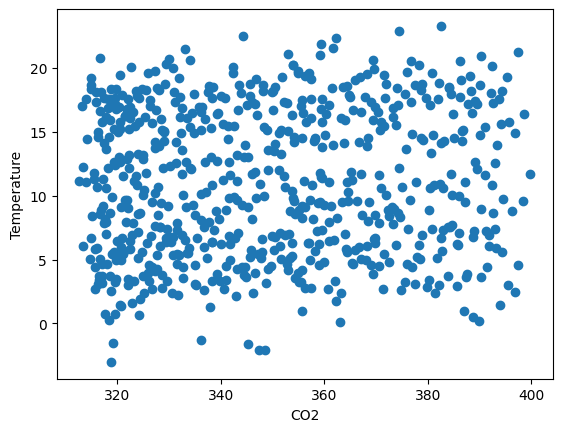

In [ ]:
fig, ax = plt.subplots()
ax.scatter(merged['Interpolated'], merged['AverageTemperature'])

ax.set_xlabel('CO2')
ax.set_ylabel('Temperature')
plt.show()

In [ ]:
merged.index

DatetimeIndex(['1958-03-01', '1958-04-01', '1958-05-01', '1958-06-01',
               '1958-07-01', '1958-08-01', '1958-09-01', '1958-10-01',
               '1958-11-01', '1958-12-01',
               ...
               '2012-12-01', '2013-01-01', '2013-02-01', '2013-03-01',
               '2013-04-01', '2013-05-01', '2013-06-01', '2013-07-01',
               '2013-08-01', '2013-09-01'],
              dtype='datetime64[ns]', name='Date', length=667, freq=None)

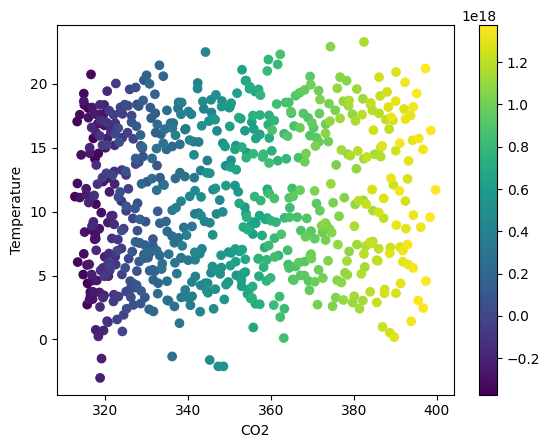

In [ ]:
fig, ax = plt.subplots()
im = ax.scatter(
    merged['Interpolated'],
    merged['AverageTemperature'],
    c=merged.index
)

ax.set_xlabel('CO2')
ax.set_ylabel('Temperature')
fig.colorbar(im, ax=ax)
plt.show()

### **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>PRO VÁS</font>**

Vytvořte bodový graf (rozptylový graf) závislosti $CO_2$ na teplotě:
* barevně označte body podle roku: 60, 70, 80, 90, 00 a 10.

*Nápověda - vytvořte další sloupec na základě `Date`, který bude udávat, ze kterých let je pozorování.

<img src="https://drive.google.com/uc?export=view&id=1iXzUShuU9LtEw_OkMSnkl0CvpCYQStDL" alt="Matplotlib: úkol pro vás" title="Matplotlib: task for you" align="center" width="750px" hspace="30px" vspace="10px"/>


## Ukládání grafů

Chcete-li uložit graf vytvořený pomocí matplotlibu, můžete použít funkci `plt.savefig()`. Zde je návod, jak to můžete udělat:
* po vytvoření grafu přidejte před volání funkce `plt.show()` nebo na konec skriptu následující řádek kódu
```python
plt.savefig('filename.png')
```
Nahraďte `'filename.png'` požadovaným názvem, příponou souboru a cestou k souboru. Můžete zadat různé formáty souborů, například PNG, JPEG, PDF, SVG atd.

Pokud chcete graf uložit do konkrétního adresáře, nezapomeňte uvést příslušnou cestu. Například `'path/to/save/directory/filename.png'`.




In [ ]:
fig.set_size_inches([10,6])
fig.savefig('temp_co2_60_10.png')

Funkce `plt.savefig()` poskytuje další parametry, které umožňují přizpůsobit uložený obrázek. Zde jsou některé běžně používané parametry:
* `dpi` (body na palec): Určuje rozlišení nebo kvalitu uloženého obrázku. Vyšší hodnoty znamenají obrázek s vyšším rozlišením.
* `bbox_inches`: Určuje část obrázku, která se má uložit. Ve výchozím nastavení se uloží celý obrázek, ale můžete zadat různé volby, například 'tight', které odstraní další bílé místo kolem obrázku. Příklad: plt.savefig('filename.png', bbox_inches='tight')
* `transparent`: Určuje, zda má mít uložený obrázek průhledné pozadí.
* `pad_inches`: Přidá výplň kolem uloženého obrázku, aby se zabránilo odříznutí prvků. Velikost výplně můžete zadat v palcích. Příklad: plt.savefig('jméno souboru.png', pad_inches=0.5)


<img src="https://drive.google.com/uc?export=view&id=1UO2urRciECzoKE_vHy4RMGfFbkOWOGlW" alt="SDA logo" align="left" width="100px" hspace="10px" vspace="10px"/>
<br>

# Úkoly

## **<font color='#306998'>Úkol </font><font color='#ffd33b'>1.1</font>**

Vytvořte funkci pro vytvoření bodového grafu (korelačního diagramu) s osami X, Y a 3. rozměrem - barvou bodů. Funkci zavolejte na libovolné 2 datové sady, na kterých jsme pracovali.

In [ ]:
url='https://raw.githubusercontent.com/matzim95/ML-datasets/master/weather.csv'

weather=pd.read_csv(
    url,
    parse_dates=True,
    index_col='date'
)

In [ ]:
weather.head()

,precipitation,temp_max,temp_min,wind,weather
date,,,,,
2012-01-01,0.0,12.8,5.0,4.7,drizzle
2012-01-02,10.9,10.6,2.8,4.5,rain
2012-01-03,0.8,11.7,7.2,2.3,rain
2012-01-04,20.3,12.2,5.6,4.7,rain
2012-01-05,1.3,8.9,2.8,6.1,rain


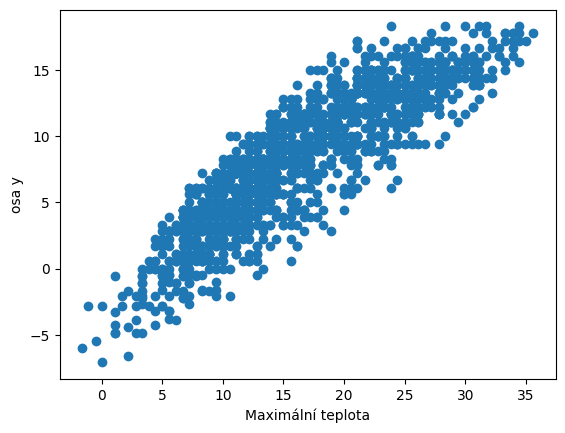

In [ ]:
def scatter_plot( alfa, beta, gama,osa_x="osa x", osa_y="osa y"):
  fig, ax = plt.subplots()
  im = ax.scatter( alfa, beta, c=gama)
  ax.set_xlabel(osa_x)
  ax.set_ylabel(osa_y)
  fig.colorbar(im, ax=ax)
  plt.show()

scatter_plot(weather['temp_max'],weather['temp_min'],weather.index,"Maximální teplota")


## **<font color='#306998'>Úkol </font><font color='#ffd33b'>1.2</font>**

Vytvořte krabicový graf pro soubor dat o počasí, který zobrazuje rozložení srážek (precipitation) podle typu počasí.

In [ ]:
url='https://raw.githubusercontent.com/matzim95/ML-datasets/master/weather.csv'

weather=pd.read_csv(
    url,
    parse_dates=True,
    index_col='date'
)

## **<font color='#306998'>Úkol </font><font color='#ffd33b'>1.3</font>**

Vytvořte sloupcový graf s chybovými úsečkami pro sadu dat o počasí zobrazující průměrné srážky podle typu počasí, přičemž chybové úsečky ukazují směrodatnou odchylku od průměrných srážek.

## **<font color='#306998'>Úkol </font><font color='#ffd33b'>1.4</font>**

Vytvořte seskupený graf zobrazující 5 vybraných měst a počet mužů a žen v každém městě.

Upravte znaménka na ose Y (např. přidejte čárky za tisíce), přidejte hodnoty nad sloupce.

<img src="https://drive.google.com/uc?export=view&id=1UO2urRciECzoKE_vHy4RMGfFbkOWOGlW" alt="SDA logo" align="left" width="100px" hspace="10px" vspace="10px"/>

# 2. Seaborn

Seaborn je knihovna pro vizualizaci dat v jazyce Python postavená nad Matplotlibem. Poskytuje vysokoúrovňové rozhraní pro vytváření atraktivní a informativní statistické grafiky.

<img src="https://drive.google.com/uc?export=view&id=1iYWtn_YCfkk30BHSvPHgKZi6UUN0kPwA" alt="Seaborn: tabularní data" title="Seaborn: logo" align="center" width="500px" hspace="30px" vspace="10px"/>

Zde je několik klíčových informací o Seabornu:
* **<font color='##13e5e1'>zjednodušená syntaxe</font>**: optimalizované funkce a výchozí nastavení pro běžné typy grafů umožňují vytvářet vizuálně přitažlivé grafy s minimem kódu.
* **<font color='##13e5e1'>statistické vizualizace</font>**: tato knihovna je užitečná zejména pro zkoumání vztahů mezi proměnnými, vizualizaci rozdělení a zvýraznění zákonitostí v datech. Navíc rozšiřuje možnosti knihovny Matplotlib o další statistické funkce. Obsahuje funkce, jako jsou regresní graf, korelační heatmapa, kategoriální grafy, vizualizace časových řad a podporu statistických anotací.
* **<font color='##13e5e1'>Integrace s Pandas</font>**: bezproblémově se integruje s populární knihovnou Pandas pro manipulaci s daty. Jako vstup může přímo přijímat Pandas DataFrame, což je vhodné pro práci s tabulkovými daty.
* **<font color='##13e5e1'>Atraktivní výchozí styly</font>**: obsahuje estetické výchozí styly a palety barev.

Seaborn je celkově výkonná knihovna pro vizualizaci dat, zejména v oblasti statistické grafiky. Doplňuje Matplotlib a Pandas a usnadňuje vytváření krásných a informativních vizualizací s minimálním úsilím.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from IPython.display import display
pd.plotting.register_matplotlib_converters()

In [ ]:
url = 'https://raw.githubusercontent.com/matzim95/ML-datasets/master/wine.csv'
wine = pd.read_csv(url)
wine

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline,Class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,one
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,one
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,one
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,one
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,one
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,three
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,three
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,three
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,three


## Bodový graf s regresním modelem

Největší výhodou používání aplikace Seaborn je množství funkcí pro tvorbu grafů. Například **<font color='##13e5e1'>vytvoření bodového grafu v kombinaci s regresním modelem</font>** je pouze jeden řádek kódu pomocí funkce `sns.lmplot()`.

To lze provést tímto způsobem:
* Předáním objektu DataFrame do argumentu data a zároveň předáním názvů sloupců do argumentů x a y.

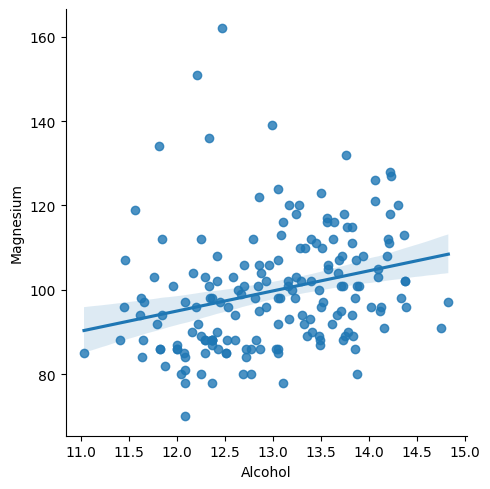

In [ ]:
sns.lmplot(x='Alcohol', y='Magnesium', data=wine)
plt.show()

Seaborn ve skutečnosti nemá speciální funkci pro vykreslení bodového grafu. K vytvoření tohoto grafu použijeme funkci Seaborn `sns.lmplot()`, která nám umožňuje sestrojit a vykreslit regresní přímku.

Každá funkce vykreslování má naštěstí několik užitečných možností, které lze nastavit. Zde se dozvíte, jak můžeme funkci lmplot() přizpůsobit vašim potřebám:
* nastavte `fit_reg = False`, abyste odstranili regresní přímku, protože chceme bodový graf.
* nastavte `hue = 'Class'`, aby se naše body zbarvily podle třídy příkladu.

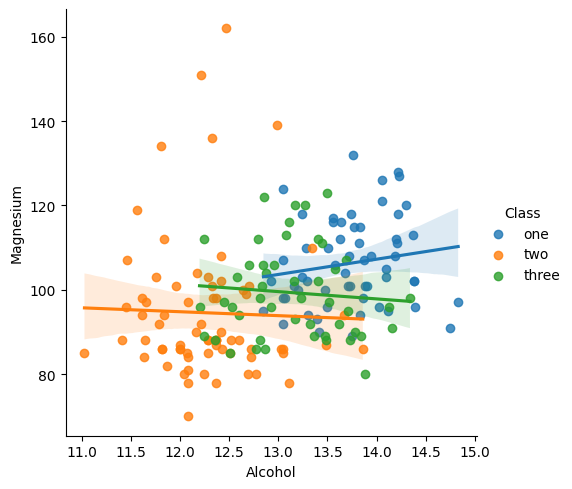

In [ ]:
sns.lmplot(
    x='Alcohol',
    y='Magnesium',
    data=wine,
    #fit_reg=False,
    hue='Class'
)

plt.show()

### **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>PRO VÁS</font>**

Pomocí knihovny seaborn vytvořte graf rozptylu znázorňující vztah mezi koncentrací alkoholu a intenzitou barvy:
* jako kategorii zadejte třídu vína
* zahrňte lineární regresní přímku pro každou třídu vína zvlášť
* naformátujte graf
    * přidejte popisy os, název,
    * změňte natočení hodnot na ose X,
    * přidejte do grafu mřížku.

<img src="https://drive.google.com/uc?export=view&id=1Mc0N-nUTgqO_HhzJIvpHgN-95a12aPWL" alt="Matplotlib: úkol pro vás" title="Matplotlib: task for you" align="center" width="750px" hspace="30px" vspace="10px"/>


## Box plot

In [ ]:
# wine.iloc[:,5:-2]

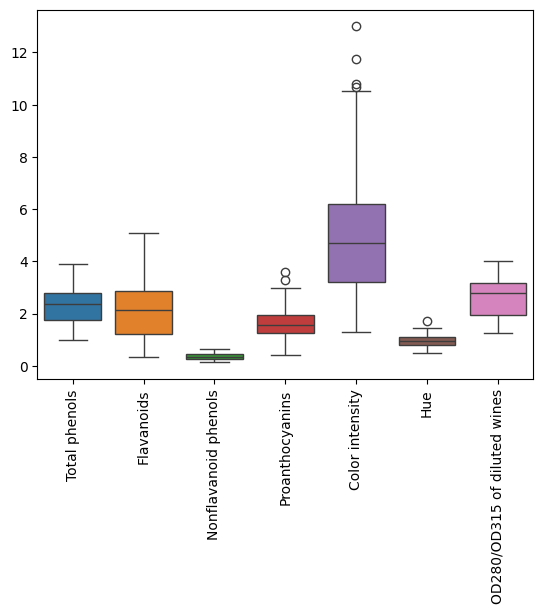

In [ ]:
g=sns.boxplot(data=wine.iloc[:, 5: -2])
g.xaxis.set_tick_params(rotation=90)

### **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>PRO VÁS</font>**

Vytvořte v modulu seaborn krabicový graf, ve kterém znázorníte, jak se obsah alkoholu liší podle stupně vína.

<img src="https://drive.google.com/uc?export=view&id=1pYMawR-A-Cayk4aYRk39IWZwDkL6JZsN" alt="Matplotlib: úkol pro vás" title="Matplotlib: task for you" align="center" width="750px" hspace="30px" vspace="10px"/>


## Houslový graf (Violin plot)

Další výhodou Seabornu je, že má **<font color='##13e5e1'>předdefinované styly</font>**. Výchozí je "whiteegrid".

Zde jsme při vytváření houslového grafu změnili styl z výchozího `"whiteegrid"` na `"darkgrid"`. Takový graf zobrazuje rozložení hodnot podobným, ale trochu jiným způsobem než boxplot.

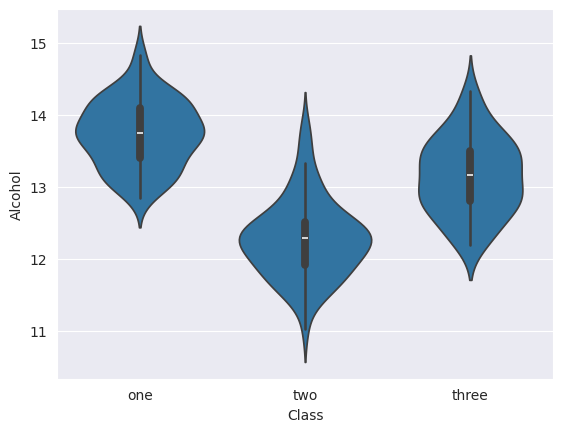

In [ ]:
sns.set_style('darkgrid')

sns.violinplot(x='Class', y='Alcohol', data=wine)
plt.show()

Houslové grafy jsou skvělé pro vizualizaci distribuce. Protože je však v našem souboru dat pouze 170 vín, můžeme jednoduše zobrazit každý bod - pomocí swarmplotu zobrazíme polohu každého bodu a poskládáme ty s podobnými hodnotami.

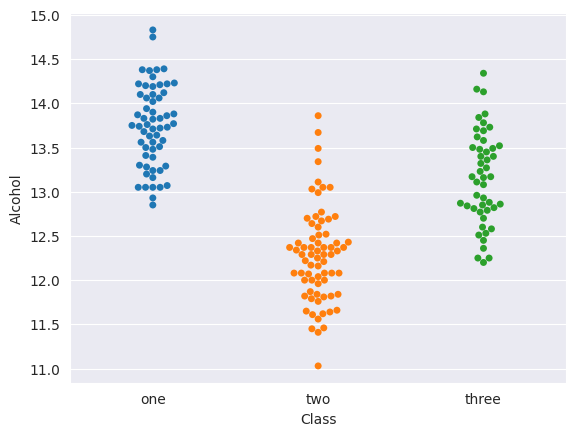

In [ ]:
sns.swarmplot(x='Class', y='Alcohol', data=wine, hue='Class')
plt.show()

Kombinujte to nejlepší z několika typů grafů a knihoven:
* Nejprve zvětšíme náš obrázek pomocí Matplotlib.
* Poté vykreslíme violinplot s parametrem `inner=None`.
* Uvnitř houslového grafu (violin plot) nakreslíme swarmplot s černými body.
* Nakonec nastavíme nadpis pomocí Matplotlibu.

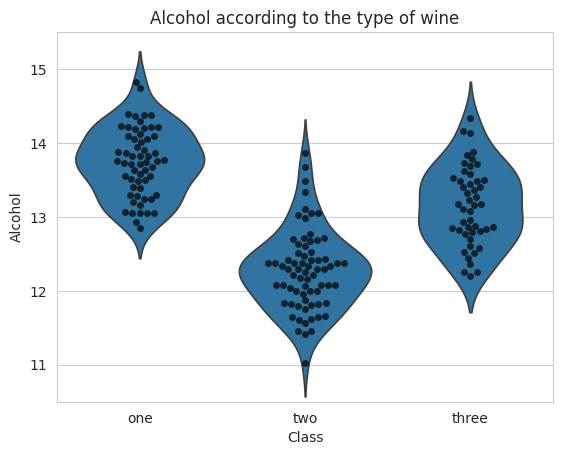

In [ ]:
sns.set_style('whitegrid')

sns.violinplot(x='Class', y='Alcohol', data=wine, inner=None)
sns.swarmplot(x='Class', y='Alcohol', data=wine, color='k', alpha=0.7)

plt.ylim([10.5, 15.5])
plt.title('Alcohol according to the type of wine')
plt.show()

Vytvoření tohoto grafu bychom jistě mohli zopakovat pro každou funkci. Můžeme však také tyto informace spojit do jednoho sloupce pomocí funkce `pd.melt()`.

Nyní můžeme vykreslit swarmplot pomocí melted_df, ale tentokrát s `x="stat"` a `y="value"`, takže naše grafy budou oddělené. Atribut `hue ="Class"` nám umožní obarvit body podle typu vína.

In [ ]:
wine.columns

Index(['Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium',
       'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline', 'Class'],
      dtype='object')

In [ ]:
melted_df = pd.melt(
    wine[[
        'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
        'Proanthocyanins', 'Color intensity', 'Hue',
        'OD280/OD315 of diluted wines', 'Class'
    ]],
    id_vars='Class',
    var_name='stat'
)
melted_df

,Class,stat,value
0,one,Total phenols,2.80
1,one,Total phenols,2.65
2,one,Total phenols,2.80
3,one,Total phenols,3.85
4,one,Total phenols,2.80
...,...,...,...
1241,three,OD280/OD315 of diluted wines,1.74
1242,three,OD280/OD315 of diluted wines,1.56
1243,three,OD280/OD315 of diluted wines,1.56
1244,three,OD280/OD315 of diluted wines,1.62


In [ ]:
import warnings
# warnings.simplefilter('always', category=UserWarning)
warnings.filterwarnings("ignore")

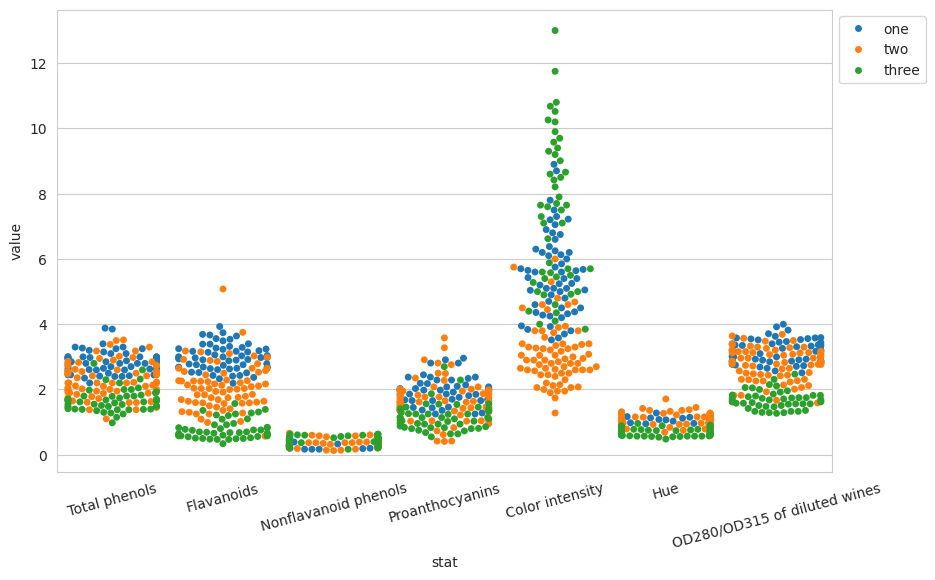

In [ ]:
plt.figure(figsize=(10, 6))

sns.swarmplot(x='stat', y='value', data=melted_df, hue='Class')

plt.legend(bbox_to_anchor=(1, 1), loc=2)
plt.xticks(rotation=15)
plt.show()

## Heatmapy

Heatmapa je **<font color='##13e5e1'>grafická reprezentace dat, kde jsou hodnoty matice reprezentovány jako barvy</font>**. Seaborn poskytuje pohodlnou funkci pro vytváření heatmap s názvem `sns.heatmap()`.

Zde je příklad vytvoření heatmapy pomocí modulu Seaborn:

In [ ]:
wine.drop('Class', axis=1).corr()

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline,Class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,one
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,one
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,one
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,one
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,one
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,three
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,three
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,three
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,three


In [ ]:
corr = wine.drop('Class', axis=1).corr()
corr

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
Alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Alcalinity of ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Total phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoid phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
Color intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


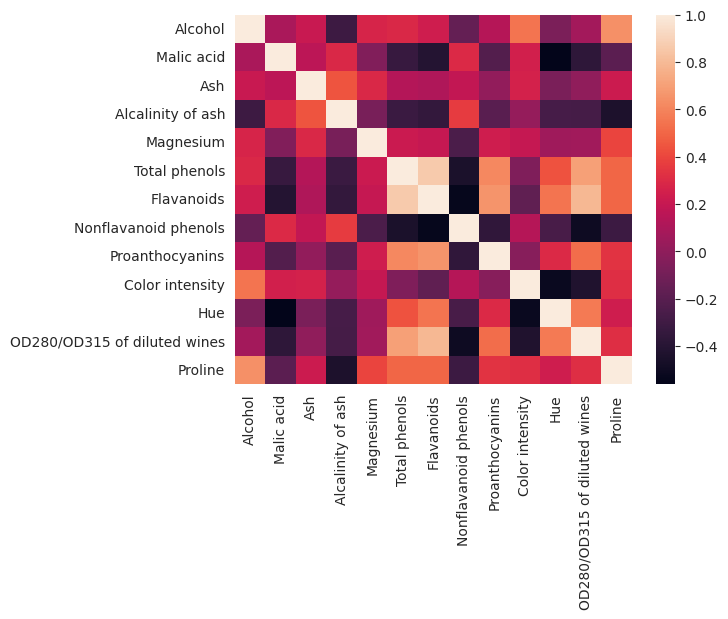

In [ ]:
sns.heatmap(corr)
plt.show()

### **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>PRO VÁS</font>**

Vytvořte graf, tj. heatmapu, zobrazující korelaci mezi proměnnými z databáze vín:
* do čtverců kromě barvy vložte hodnotu korelace.
* změňte výchozí barevnou škálu - např. zeleno-modrá, modro-červená.

<img src="https://drive.google.com/uc?export=view&id=1kKRYjYJU-Lkxu2WBNw5dLG_yOiLgTSc1" alt="Matplotlib: úkol pro vás" title="Matplotlib: task for you" align="center" width="750px" hspace="30px" vspace="10px"/>


## Histogram s KDE (kernel density estimation)
V Seabornu je funkce `displot()` určena k vytváření různých grafů pro jednorozměrná rozdělení. Podporuje různé typy grafů, včetně histogramů, **<font color='##13e5e1'>kernelový odhad hustoty pravděpodbnosti (KDE) </font>**, a kobercové grafy (rug ploty). Při použití funkce `displot()` s parametrem 'kind' nastaveným na 'kde' se vygeneruje graf KDE.

Graf KDE vizualizuje **<font color='##13e5e1'>odhadovanou funkci hustoty pravděpodobnosti spojité proměnné</font>**. Poskytuje hladkou křivku, která aproximuje základní rozdělení dat.

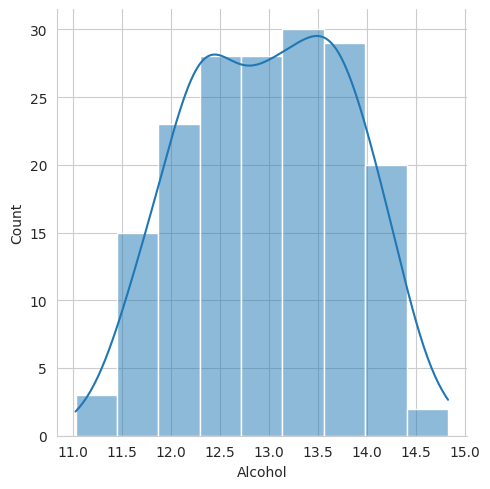

In [ ]:
sns.displot(wine.Alcohol, kde=True)
plt.show()

## Countplot

Countplot je **<font color='##13e5e1'>typ sloupcového grafu, ve kterém je počet nebo četnost jednotlivých kategorií</font>** v kategoriální proměnné reprezentován výškou sloupců. Seaborn poskytuje pohodlnou funkci nazvanou `sns.countplot()`, která slouží k vytváření countplotů.



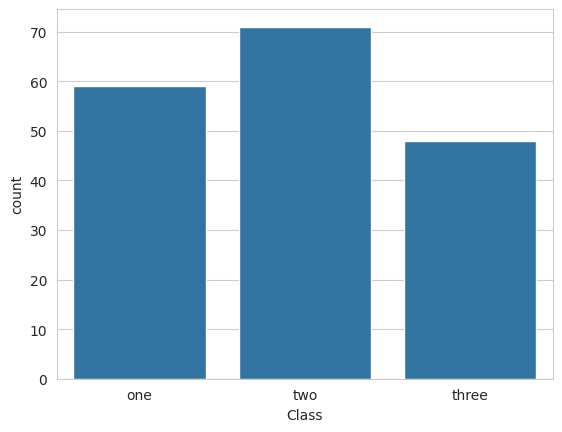

In [ ]:
sns.countplot(x='Class', data=wine)
plt.show()

## KDE & společné grafy pro 2D data

Pro vytvoření 2D grafu odhadu hustoty jádra (KDE) v programu Seaborn můžete použít funkci `sns.kdeplot()`. Tento graf umožňuje vizualizovat hustotu dvourozměrného souboru dat, který představuje společné rozdělení dvou spojitých proměnných.

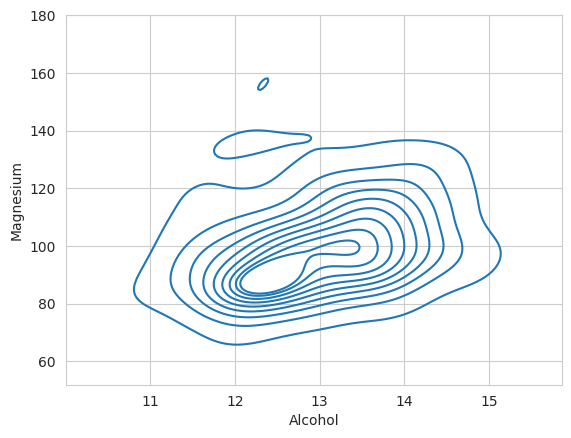

In [ ]:
sns.kdeplot(
    data=wine,
    x='Alcohol',
    y='Magnesium'
)
plt.show()

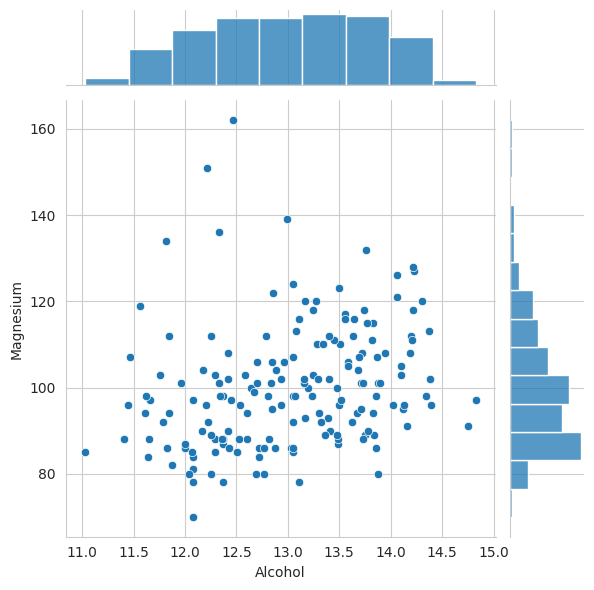

In [ ]:
sns.jointplot(
    data=wine,
    x='Alcohol',
    y='Magnesium'
)
plt.show()

### **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>PRO VÁS</font>**

Aktualizujte výše uvedený graf kdeplot a:
* definujte počet úrovní hustoty jako 10
* přidejte barevnou škálu
    * barva čáry i výplň mezi vrstvami - čím blíže ke středu, tím intenzivnější je barva
* vedle grafu umístěte legendu s barevnou škálou

<img src="https://drive.google.com/uc?export=view&id=15FB8Svo8aHiKBLgNvPRMrQCFKp7rws9L" alt="Matplotlib: úkol pro vás" title="Matplotlib: task for you" align="center" width="750px" hspace="30px" vspace="10px"/>

*Nápověda: Použijte cmap='viridis'*

In [ ]:
from plotnine import *
from plotnine.data import mpg

In [ ]:
mpg.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


<img src="https://drive.google.com/uc?export=view&id=1UO2urRciECzoKE_vHy4RMGfFbkOWOGlW" alt="SDA logo" align="left" width="100px" hspace="10px" vspace="10px"/>
<br>

# TASKS

## **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>2.1</font>**

Pro následující soubor dat:
```python
from plotnine import *
from plotnine.data import mpg

mpg.head()
```
Vytvořte histogram s objemem motoru ("displ"):
* definujte barvu sloupců
* přidejte popis osy a název grafu
* změňte téma (theme) grafu (pozadí, např. z tmavě šedé na bílou bez mřížky)

## **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>2.2</font>**

Vytvořte graf znázorňující rozložení koncentrace alkoholu ve víně:
* označte osy X, Y a přidejte nadpis
* přidejte svislou čáru znázorňující průměrnou hodnotu koncentrace

## **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>2.3</font>**

Vytvořte graf znázorňující počet vín podle tříd. Dbejte na estetickou stránku grafu.

## **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>2.4</font>**

Pro datovou sadu `mpg` definovanou v úloze 2.1 vytvořte společný graf zobrazující vztah objemu motoru ("displ") a počtu mil na galon na dálnici ("hwy"):
1. Jako barvu uveďte třídu vozu.
2. Přidejte do grafu nadpis a mřížku grafu a změňte písmo (poznámka - jiné než v matplotlib).

## **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>2.5</font>**

Vytvořte graf s kernelovým odhadem hustoty zobrazující vztah mezi objemem motoru a počtem ujetých kilometrů na galon na dálnici.
1. Přidejte do grafu výplň a definujte barevnou škálu, která se bude lišit od výchozí.
1. Omezte plochu grafu - osa X: (0,7), osa Y: (5,40).

## **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>2.6</font>**

Vytvořte heatmapu pro všechny spojité proměnné ze sady `mpg` a zobrazte korelaci mezi proměnnými.
* Přidejte hodnoty korelace jako anotace do buněk heatmapy.
* Definujte barevnou škálu a formát anotací.

## **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>2.7</font>**

Vytvořte graf znázorňující rozložení objemu motoru ("displ") podle třídy vozidla.
1. Do grafu zahrňte dva typy grafů najednou (např. boxplot + swarm).
1. Změňte barevnou paletu

## **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>2.8</font>**

Vytvořte graf `lmplot` zobrazující vztah mezi objemem motoru ("displ") a počtem válců ("cyl").
1. Dbejte na estetiku grafu.
1. Přidejte do grafu anotaci označující závislost mezi zobrazenými proměnnými.

*Nápověda: můžete použít*
```python
from scipy.stats import pearsonr
corr, _ = pearsonr(mpg.displ, mpg.cyl)
```

## **<font color='#306998'>ÚKOL </font><font color='#ffd33b'>2.9</font>**

Na základě níže uvedených dat:
1. Vytvořte graf vztahu mezi spotřebou piva a vína, jako kategorie označte kontinent.
1. Vytvořte graf s mírami rozložení spotřeby čistého alkoholu podle jednotlivých kontinentů.

In [ ]:
url='https://raw.githubusercontent.com/matzim95/ML-datasets/master/drinks.csv'
alcohols=pd.read_csv(url)
alcohols.head()